# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. Unit of analysis + time window

**One row = one article, for one client, on one day.**

- Table: `fact_content_daily_performance`
- Grain: `(client_hash_id, content_hash_id, report_date)` — exactly one row per combination
- Time window: `month=2026-03` (mid-panel month, used for all development).
  The `_sample` file (June 2026) is the sealed final month and is **not** used here —
  it's the natural outcome window for any past→future label, so using it now would leak the future into development.

Verified below: grain uniqueness check, and the row count / date span for this window.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import duckdb
from huggingface_hub import login, hf_hub_download
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))
repo = "FlyRank/internship-warehouse"

fact_path = hf_hub_download(repo_id=repo, repo_type="dataset",
                             filename="fact_content_daily_performance/month=2026-03/data_0.parquet")

con = duckdb.connect()
con.sql(f"CREATE OR REPLACE VIEW fact AS SELECT * FROM read_parquet('{fact_path}')")

# grain check: should return 0 rows
grain_check = con.sql("""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS n
    FROM fact
    GROUP BY 1, 2, 3
    HAVING COUNT(*) > 1
""").df()
print("Duplicate grain rows found:", len(grain_check))
grain_check

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate grain rows found: 0


,report_date,client_hash_id,content_hash_id,n


In [3]:
from huggingface_hub import login, hf_hub_download
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))
repo = "FlyRank/internship-warehouse"

dim_clients_path = hf_hub_download(repo_id=repo, repo_type="dataset",
                                    filename="dim_clients.parquet")
dim_content_path = hf_hub_download(repo_id=repo, repo_type="dataset",
                                    filename="dim_content.parquet")
query90d_path     = hf_hub_download(repo_id=repo, repo_type="dataset",
                                    filename="fact_content_query_90d.parquet")

con.sql(f"CREATE OR REPLACE VIEW dim_clients AS SELECT * FROM read_parquet('{dim_clients_path}')")
con.sql(f"CREATE OR REPLACE VIEW dim_content AS SELECT * FROM read_parquet('{dim_content_path}')")
con.sql(f"CREATE OR REPLACE VIEW query90d AS SELECT * FROM read_parquet('{query90d_path}')")

dim_clients.parquet: reconstructing file:   0%|          |  0.00B / 3.38kB            

dim_clients.parquet: downloading bytes:           |  0.00B            

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

fact_content_query_90d.parquet: reconstructing file:   0%|          |  0.00B / 60.7MB            

fact_content_query_90d.parquet: downloading bytes:           |  0.00B            

In [4]:
for view in ["fact", "dim_clients", "dim_content", "query90d"]:
    n = con.sql(f"SELECT COUNT(*) AS n_rows FROM {view}").df()["n_rows"][0]
    print(f"{view}: {n:,} rows")

fact: 9,841,378 rows
dim_clients: 104 rows
dim_content: 519,606 rows
query90d: 2,414,248 rows


In [5]:
con.sql("SELECT * FROM dim_clients LIMIT 5").df()

,client_hash_id,is_active,has_gsc_access,has_ga4_access,access_profile,client_created_date,client_updated_date,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,True,True,True,gsc_and_ga4,2026-04-15,2026-06-27,NaT,2026-05-22
1,client_05475c07ed21a83a,True,False,False,no_search_or_analytics_access,2026-04-01,2026-06-27,NaT,NaT
2,client_06d356715a8ff3b6,True,True,True,gsc_and_ga4,2026-03-23,2026-07-05,2026-04-10,2026-04-06
3,client_0797ff3a1fc9a6a5,True,False,False,no_search_or_analytics_access,2025-05-26,2026-06-27,2025-11-05,NaT
4,client_08a6a72ff48e62c0,True,True,False,gsc_only,2025-05-26,2026-06-27,2025-09-24,NaT


In [6]:
con.sql("SELECT * FROM dim_content LIMIT 5").df()

,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


In [7]:
con.sql("SELECT * FROM query90d LIMIT 5").df()

,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


In [8]:
con.sql("SELECT * FROM fact LIMIT 5").df()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [9]:
window_check = con.sql("""
    SELECT COUNT(*) AS n_rows,
           MIN(report_date) AS first_day,
           MAX(report_date) AS last_day,
           COUNT(DISTINCT content_hash_id) AS n_articles,
           COUNT(DISTINCT client_hash_id) AS n_clients
    FROM fact
""").df()
window_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows,first_day,last_day,n_articles,n_clients
0,9841378,2026-03-01,2026-03-31,331437,55


*Table: `fact_content_daily_performance`
Grain: `(client_hash_id, content_hash_id, report_date)` — verified below, exactly one row per combination, no duplicates.
Time window: `month=2026-03` (mid-panel month, used for all development).
  The `_sample` file (June 2026) is the sealed final month and is **not** used here —
  it's the natural outcome window for any past→future label, so using it now would leak the future into development.*

**Verified (see queries below):**

*Grain check: 0 duplicate `(report_date, client_hash_id, content_hash_id)` combinations — confirms the grain claim.*

*Row count / span: **9,841,378 rows**, covering the full month `2026-03-01` → `2026-03-31`, across **331,437 distinct articles** and **55 *distinct clients**.*

*- Note: `dim_clients` has 104 total clients, but only 55 appear in the March fact table — this is expected, since the panel is unbalanced (clients differ in `gsc_data_start` / `ga4_data_start`, and some have `has_gsc_access = False` / `has_ga4_access = False` entirely, so they never produce daily performance rows). This imbalance is revisited in §4 (Data limits).*

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

**Lane:** AI Referral Opportunity — identifying which articles are candidates for AI-referral
traffic, using signals knowable before the observation window. This carries forward the lane
defined in W01/W02, now built on the full warehouse (`fact_content_daily_performance`) rather
than the starter CSV.

**Feature** — knowable before the outcome, used as model inputs:
- `gsc_impressions` — historical search impressions (same role as `impressions_90d` in the starter CSV)
- `gsc_avg_position` — historical average ranking position
- `word_count` (from `dim_content`) — static content attribute, fixed at creation

**Label** — the outcome we're predicting / scoring toward:
- `sessions_ai` — the warehouse's direct measure of AI-referral traffic, the same signal as
  `ai_sessions_90d` in the starter CSV. Aggregated over the window (e.g. any day in March with
  `sessions_ai > 0`), since — as established in W01 — this remains too rare for classification
  and should stay ranking/scoring.

**Context** — identifiers and metadata, not fed to the model as signal:
- `client_hash_id`, `content_hash_id`, `report_date`, `month`

**Excluded** — deliberately left out, with reason:
- `gsc_sum_position` — redundant with `gsc_avg_position`; keeping both invites a model to over-weight the same underlying signal.
- `client_has_gsc` / `gsc_data_available` / `client_has_ga4` / `ga4_data_available` — these are availability flags, not performance signals; used only to *filter* rows (see step 3), not as features, since a model shouldn't learn "clicks depend on whether we happened to have GSC access."
- Any column that would require peeking inside the label's own time window (e.g. computing "past" impressions using days that overlap the forward window) — excluded on principle to avoid leakage, per the lecture's warning that circular success (predicting an outcome from data that already encodes it) produces a meaningless score.
- Raw `dim_content` identity-adjacent fields (`keyword_hash_id`, `url_hash_id`) — hashed but still not meaningful as model features; they're join keys, not signal.

**Findings from validation (informs Excluded + carries into step 4):**
- `gsc_avg_position` present in only 37% of fact rows; `ga4_sessions` in only 69%. Both are true NULLs (no data), not zeros — must be excluded from row-level averages without explicit NULL-safe handling (`AVG()` already skips NULLs correctly by default, but any manual sum/count logic must not treat NULL as 0).
- `word_count` populated for only 67.6% of articles in `dim_content` (224,008 / 331,437) — using it as a feature drops or requires imputation for ~32% of articles.
- **Additional exclusion:** rows joined to `dim_content.is_deleted = True` (101,559 of 519,606 content rows, ~19.5%) are excluded from feature-building — a deleted article's historical performance is not a meaningful signal for predicting future click growth.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Confirm the feature/context columns actually exist and have real values in our March slice
con.sql("""
    SELECT
        COUNT(*) AS n_rows,
        COUNT(gsc_impressions)  AS n_impressions_present,
        COUNT(gsc_clicks)       AS n_clicks_present,
        COUNT(gsc_avg_position) AS n_position_present,
        COUNT(ga4_sessions)     AS n_sessions_present
    FROM fact
""").df()

,n_rows,n_impressions_present,n_clicks_present,n_position_present,n_sessions_present
0,9841378,9841378,9841378,3611061,6822637


In [11]:
# Confirm word_count is populated in dim_content for the articles present in March fact
con.sql("""
    SELECT COUNT(*) AS n_content_rows,
           COUNT(word_count) AS n_with_word_count
    FROM dim_content
    WHERE content_hash_id IN (SELECT DISTINCT content_hash_id FROM fact)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_content_rows,n_with_word_count
0,331437,224008


In [12]:
con.sql("""
    SELECT
        COUNT(DISTINCT f.content_hash_id) AS content_ids_in_fact,
        COUNT(DISTINCT d.content_hash_id) AS matched_in_dim_content
    FROM fact f
    LEFT JOIN dim_content d USING (content_hash_id)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_ids_in_fact,matched_in_dim_content
0,331437,331437


In [13]:
con.sql("""
    SELECT
        MIN(gsc_impressions) AS min_impr, MAX(gsc_impressions) AS max_impr,
        MIN(gsc_clicks) AS min_clicks,
        MIN(gsc_avg_position) AS min_pos, MAX(gsc_avg_position) AS max_pos
    FROM fact
""").df()

,min_impr,max_impr,min_clicks,min_pos,max_pos
0,0,40084,0,0.0,498.0


In [14]:
con.sql("""
    SELECT COUNT(*) AS violations
    FROM fact
    WHERE gsc_clicks > gsc_impressions
""").df()

,violations
0,0


In [15]:
con.sql("""
    SELECT is_published, is_deleted, COUNT(*) AS n
    FROM dim_content
    GROUP BY 1, 2
""").df()

,is_published,is_deleted,n
0,True,False,411540
1,False,False,6507
2,False,True,101559


In [16]:
con.sql("""
    SELECT
        SUM(CASE WHEN d.is_deleted THEN 1 ELSE 0 END) AS fact_rows_on_deleted_content,
        COUNT(*) AS total_fact_rows
    FROM fact f
    JOIN dim_content d USING (content_hash_id)
""").df()

,fact_rows_on_deleted_content,total_fact_rows
0,201090.0,9841378


In [17]:
con.sql("""
    SELECT
        COUNT(*) AS n_rows,
        COUNT(sessions_ai) AS n_sessions_ai_present,
        ROUND(100.0 * (COUNT(*) - COUNT(sessions_ai)) / COUNT(*), 2) AS pct_missing,
        SUM(CASE WHEN sessions_ai > 0 THEN 1 ELSE 0 END) AS n_rows_with_ai_sessions,
        ROUND(100.0 * SUM(CASE WHEN sessions_ai > 0 THEN 1 ELSE 0 END) / COUNT(*), 4) AS pct_rows_with_ai_sessions
    FROM fact
""").df()

,n_rows,n_sessions_ai_present,pct_missing,n_rows_with_ai_sessions,pct_rows_with_ai_sessions
0,9841378,6822637,30.67,5534.0,0.0562


*`sessions_ai` is present (non-NULL) in 69.33% of rows (6,822,637 of 9,841,378) — the same
coverage pattern as `ga4_sessions`, which makes sense since AI-referral sessions are measured
through the same GA4 pipeline and inherit its three-valued availability logic (§3). Missingness
here isn't "no data," it's mostly "no GA4 connection," same caveat as before.*

*Of the rows where it's measured, only 5,534 (0.0562% of all 9,841,378 rows) show `sessions_ai > 0`
— even rarer than the starter CSV's 6.43% base rate. That's expected, not a red flag: the starter
CSV's `ai_sessions_90d` was a *90-day rollup* per article, while this is a *single day's* count —
naturally much sparser. The right comparison isn't this daily rate against the starter's 90-day
rate directly; it's whether, once aggregated up to an article-level 90-day (or full-month) window
like the starter CSV did, the resulting base rate lands in a similar range. That aggregation is
the next real step before this can support a lift@K-style score the way W02 did on the starter
data.*

*This confirms the lane is still viable on the full warehouse, but reinforces the same point from
W01/W02: this must stay ranking/scoring, never classification — 0.0562% positive at the daily
grain is far too rare to train or evaluate a classifier against honestly.*

In [18]:
article_ai = con.sql("""
    SELECT
        content_hash_id,
        SUM(sessions_ai) AS sessions_ai_march,
        COUNT(sessions_ai) AS days_with_ga4_data
    FROM fact
    GROUP BY content_hash_id
""").df()

has_ai = article_ai["sessions_ai_march"] > 0
base_rate_march = has_ai.mean() * 100

print(f"Articles in March: {len(article_ai):,}")
print(f"Articles with any AI-referral sessions (March, GA4-connected only): "
      f"{base_rate_march:.2f}% ({has_ai.sum():,} of {len(article_ai):,})")
print(f"\nFor comparison — starter CSV base rate (90-day window): 6.43%")

Articles in March: 331,437
Articles with any AI-referral sessions (March, GA4-connected only): 1.15% (3,795 of 331,437)

For comparison — starter CSV base rate (90-day window): 6.43%


*At the article level, the March base rate is 1.15% (3,795 of 331,437 articles) — well below the
starter CSV's 6.43%. This gap is expected, not a discrepancy, for two compounding reasons:*

1. ***Denominator mismatch.** This 1.15% is measured against *all* articles in the March fact
   table, including the ~30% with no GA4 connection at all (where `sessions_ai` is structurally
   NULL, not zero — see §3). The starter CSV's 6.43% was computed on a curated 30,000-row sample
   that likely wasn't diluted the same way. Restricting the denominator to only GA4-connected
   articles would push this rate up, though not necessarily all the way to 6.43%.*

2. ***Window mismatch.** March is a single calendar month (28–31 days per article, per §4's
   history-depth check), while the starter CSV's `ai_sessions_90d` is a genuine 90-day rollup —
   roughly three months of accumulated sessions per article. A shorter window mechanically lowers
   the chance of catching at least one AI-referral session.*

*Neither of these means the lane doesn't hold on the full warehouse — it means the 6.43% figure
was never the right target to match exactly, only a sanity range. What this confirms is the
underlying shape from W01/W02: AI-referral sessions are rare at any grain tested so far (0.06%
daily, 1.15% monthly, 6.43% over 90 days) and consistently too sparse for classification. The
lane stays ranking/scoring, and any full-warehouse feature build should use a window closer to
90 days (or restrict to GA4-connected articles, or both) rather than a single month, to get a
base rate genuinely comparable to what W02's scoring work was tuned against.*

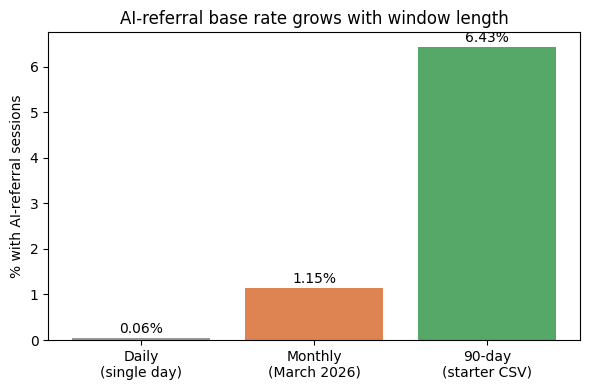

In [32]:
grains = ["Daily\n(single day)", "Monthly\n(March 2026)", "90-day\n(starter CSV)"]
rates = [0.0562, 1.15, 6.43]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(grains, rates, color=["#999999", "#DD8452", "#55A868"])
ax.set_ylabel("% with AI-referral sessions")
ax.set_title("AI-referral base rate grows with window length")
for bar, v in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("work/figures/w03_ai_rate_by_grain.png", dpi=150, bbox_inches="tight")
plt.show()

*Running the checks above told us more about this slice than the schema alone would suggest.*

***Coverage isn't uniform across columns.** `gsc_impressions` and `gsc_clicks` are fully populated in every one of the 9.84M rows — but `gsc_avg_position` only shows up in 37% of them (3.6M rows) and `ga4_sessions` in 69% (6.8M rows). That gap isn't missing data in the broken sense — it's the "two kinds of nothing" idea from the lecture: no position exists when there was nothing to rank, and no session count exists for clients without GA4 access. Both are real NULLs, not zeros, and averaging them has to respect that (letting `AVG()` skip NULLs naturally rather than manually filling gaps with 0).*

***Content metadata has real gaps too.** `word_count` — the one static, always-safe feature we planned to pull from `dim_content` — is only populated for 224,008 of 331,437 articles that actually appear in March's fact table (67.6%). Any model using it needs to either drop or explicitly impute roughly a third of rows, rather than assume completeness.*

***The join is solid.** Every `content_hash_id` in the fact table matches a row in `dim_content` (331,437 / 331,437) — no silent join failure the way the URL-key mismatch problem from the lecture would cause.*

***One quality issue worth acting on:** 201,090 of the 9,841,378 fact rows (about 2%) belong to content marked `is_deleted = True` in `dim_content`. Since a deleted article's past performance says nothing useful about future click growth, these rows should be filtered out before any feature-building — this wasn't obvious from the fact table alone and only surfaced by joining and checking `dim_content` flags.*

***No sanity violations found** — clicks never exceed impressions, and position values fall in a believable range (0–498), so the numeric columns can be trusted as-is once the NULL handling above is respected.*

*Based on this, the plan for a click-growth lane is: use `gsc_impressions`, `gsc_clicks`, `gsc_avg_position`, `ga4_sessions`, and `word_count` as features (each with its documented NULL-rate handled explicitly); use forward `gsc_clicks` change as the label; keep `client_hash_id` / `content_hash_id` / `report_date` as context only; and exclude the availability flags, the redundant `gsc_sum_position`, the raw hashed keys, and any row tied to deleted content.*

## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

**Already verified (in step 1, not repeated here):**
- Grain: 0 duplicate `(report_date, client_hash_id, content_hash_id)` combinations.
- Row count / date span: 9,841,378 rows, spanning `2026-03-01` to `2026-03-31`, across 331,437 articles and 55 clients.

**What this section adds — missing values, formalized:**
- step 2's validation queries already surfaced that `gsc_avg_position` (37% present) and `ga4_sessions` (69% present) have real gaps, and `word_count` is missing for ~32% of articles. Those were raw `COUNT()` differences at the time; this section restates them as a clean missing-values summary in one canonical place.

**What this section adds — availability, using the dataset's own trust flags:**
- Rather than inferring availability indirectly from NULL counts, this checks `gsc_data_available` / `ga4_data_available` directly, using `IS TRUE` rather than `= TRUE` — per the lecture's warning that `IS TRUE` is NULL-safe, while `= TRUE` silently drops NULL-flag rows from a count instead of surfacing them.

**Cross-check — does the flag mean what it claims?**
- If `gsc_data_available IS TRUE` is supposed to mean "a position could be computed," rows where the flag is true should have `gsc_avg_position` present, and rows where it's false/NULL should have it missing. This confirms the flag behaves as its name promises rather than assuming it.

Queries below: (1) missing-values summary as percentages, (2) `IS TRUE` availability check on both flags, (3) cross-check that the flag and the NULL pattern agree.

In [19]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
con.sql("""
    SELECT
        COUNT(*) AS n_rows,
        ROUND(100.0 * (COUNT(*) - COUNT(gsc_impressions))  / COUNT(*), 2) AS pct_missing_impressions,
        ROUND(100.0 * (COUNT(*) - COUNT(gsc_clicks))       / COUNT(*), 2) AS pct_missing_clicks,
        ROUND(100.0 * (COUNT(*) - COUNT(gsc_avg_position)) / COUNT(*), 2) AS pct_missing_position,
        ROUND(100.0 * (COUNT(*) - COUNT(ga4_sessions))     / COUNT(*), 2) AS pct_missing_sessions
    FROM fact
""").df()

,n_rows,pct_missing_impressions,pct_missing_clicks,pct_missing_position,pct_missing_sessions
0,9841378,0.0,0.0,63.31,30.67


In [20]:
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END) AS rows_gsc_available,
        ROUND(100.0 * SUM(CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_gsc_available,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS rows_ga4_available,
        ROUND(100.0 * SUM(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_ga4_available
    FROM fact
""").df()

,total_rows,rows_gsc_available,pct_gsc_available,rows_ga4_available,pct_ga4_available
0,9841378,3611061.0,36.69,413966.0,4.21


In [21]:
con.sql("""
    SELECT
        gsc_data_available,
        COUNT(*) AS n_rows,
        COUNT(gsc_avg_position) AS n_position_present,
        COUNT(*) - COUNT(gsc_avg_position) AS n_position_missing
    FROM fact
    GROUP BY gsc_data_available
""").df()

,gsc_data_available,n_rows,n_position_present,n_position_missing
0,False,6230317,0,6230317
1,True,3611061,3611061,0


In [22]:
con.sql("""
    SELECT
        ga4_data_available,
        COUNT(*) AS n_rows,
        COUNT(ga4_sessions) AS n_sessions_present,
        COUNT(*) - COUNT(ga4_sessions) AS n_sessions_missing
    FROM fact
    GROUP BY ga4_data_available
""").df()

,ga4_data_available,n_rows,n_sessions_present,n_sessions_missing
0,<NA>,3018741,0,3018741
1,False,6408671,6408671,0
2,True,413966,413966,0


In [23]:
con.sql("""
    SELECT
        ga4_data_available,
        COUNT(*) AS n_rows,
        MIN(ga4_sessions) AS min_sessions,
        MAX(ga4_sessions) AS max_sessions,
        AVG(ga4_sessions) AS avg_sessions,
        SUM(CASE WHEN ga4_sessions = 0 THEN 1 ELSE 0 END) AS n_zero_sessions
    FROM fact
    GROUP BY ga4_data_available
""").df()

,ga4_data_available,n_rows,min_sessions,max_sessions,avg_sessions,n_zero_sessions
0,<NA>,3018741,<NA>,<NA>,NaN,0.0
1,False,6408671,0,0,0.000000,6408671.0
2,True,413966,0,792,3.139891,3631.0


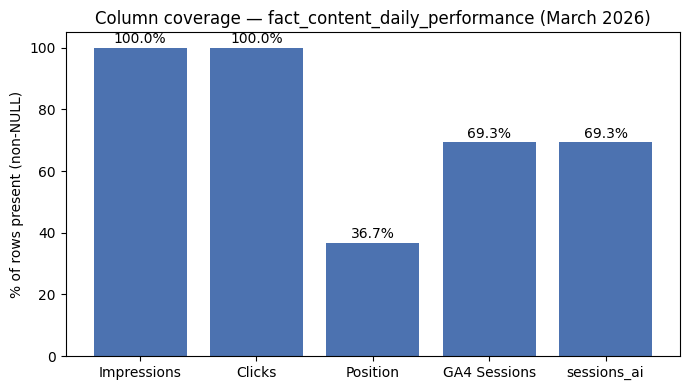

In [28]:
import matplotlib.pyplot as plt
import os

cols = ["Impressions", "Clicks", "Position", "GA4 Sessions", "sessions_ai"]
pct_present = [100.0, 100.0, 36.69, 69.33, 69.33]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cols, pct_present, color="#4C72B0")
ax.set_ylabel("% of rows present (non-NULL)")
ax.set_title("Column coverage — fact_content_daily_performance (March 2026)")
ax.set_ylim(0, 105)
for bar, v in zip(bars, pct_present):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/w03_column_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings:**

***`gsc_data_available` is a clean, reliable flag.** It aligns perfectly with `gsc_avg_position`: `True` → position always present (3,611,061 / 3,611,061 rows), `False` → position always missing (6,230,317 / 6,230,317 rows). No leakage between the two states in either direction. This flag behaves exactly as its name promises and can be trusted at face value for filtering.*

***`ga4_data_available` is three-valued, not a clean boolean.** Grouping `fact` by this flag shows:*
  - *`NULL` (3,018,741 rows, ~30.7%) — `ga4_sessions` is genuinely missing for every row in this group. This is the true "no GA4 access" case: the client never connected GA4, so nothing was ever measured.*
  - *`False` (6,408,671 rows, ~65.1%) — every single row has `ga4_sessions = 0` exactly (`min = max = avg = 0.0`, confirmed across all 6.4M rows with zero variance). This is not missing data — it's a real, measured zero: GA4 was connected and reporting, but no sessions happened that day for that article.*
  - *`True` (413,966 rows, ~4.2%) — real variation in session counts, ranging 0–792 with an average of 3.14. Notably this group *also* contains 3,631 rows with exactly 0 sessions — so even the "True" (engaged) bucket isn't purely non-zero; a day can be flagged as GA4-available-with-engagement-tracking and still register zero sessions.*

***Practical consequence for §2's feature list:** `ga4_sessions` being non-NULL in 69.33% of rows does *not* mean 69.33% of rows have meaningful GA4 signal — the vast majority of that (65.1 of the 69.33 percentage points) is the `False` group's structural zeros, not real engagement data. Treating all non-NULL `ga4_sessions` values as equally informative would quietly bias any model toward learning "most articles get ~0 GA4 traffic," which is true only because most rows are hardcoded zero, not because traffic is genuinely absent.*

***Rule adopted going forward:** use `ga4_data_available IS NOT NULL` (equivalently, `ga4_sessions IS NOT NULL`) to test "does this client have any GA4 connection at all" — this is the availability question. Use `ga4_data_available IS TRUE` separately, only when the question is "was there real, tracked engagement on this row" — this is an engagement-quality question, not an availability question, and conflating the two would misstate what any downstream feature actually measures.*

***Contrast with `gsc_data_available`:** this asymmetry between the two Google sources is itself worth remembering — GSC's flag maps 1:1 onto data presence/absence, while GA4's flag encodes an extra distinction (measured-zero vs. never-measured) that isn't obvious from the column name alone. A model or contract that assumes both flags work the same way would silently mishandle one of them.*

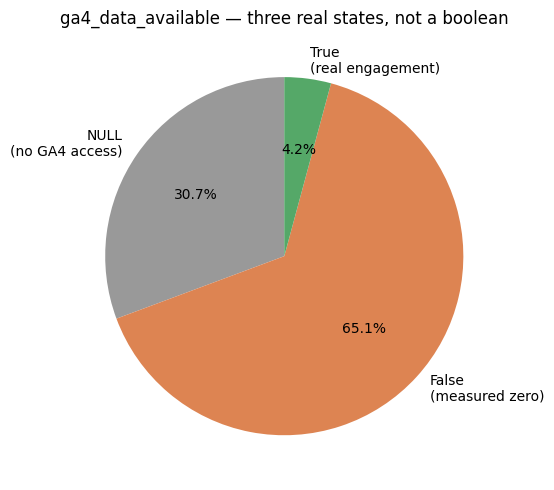

In [29]:
labels = ["NULL\n(no GA4 access)", "False\n(measured zero)", "True\n(real engagement)"]
counts = [3018741, 6408671, 413966]
colors = ["#999999", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(counts, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
ax.set_title("ga4_data_available — three real states, not a boolean")

plt.tight_layout()
plt.savefig("work/figures/w03_ga4_flag_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

The previous three sections already surfaced several limitations in passing — this section pulls them together and quantifies the ones that weren't yet measured directly, so the contract states clearly what this slice can and cannot support.

**Panel imbalance (flagged in step 1, not yet measured):** `dim_clients` has 104 total clients, but only 55 appear in the March 2026 fact table. Some of that gap is expected — `dim_clients.access_profile` includes values like `no_search_or_analytics_access`, meaning some clients were never wired to either data source at all. But some clients with access may still be absent from March specifically because their `gsc_data_start` / `ga4_data_start` postdates the window, or their history simply doesn't reach back that far. This needs a query against `dim_clients` to separate "never had access" from "has access but no March history" — those are two different limitations with different downstream consequences.

**Content coverage gaps (quantified in step 2, restated here as a limit):** `word_count` is missing for ~32% of articles, and `dim_content` overall has ~19.5% deleted content mixed in (2% of which still appears in the March fact table). Any feature relying on content metadata inherits this gap — it's not something a query can fix, only something a model must account for.

**GA4's three-valued flag (discovered in step 3, restated as a limit):** the dataset cannot distinguish "no GA4 access" cleanly from "GA4 access with zero engagement" without using the flag correctly — a naive read of `ga4_sessions IS NULL` alone would misclassify 65% of the panel as missing when it's actually a real, measured zero.

**Structural limit worth stating plainly:** this is a single mid-panel month (March 2026). No feature or label built from it can capture seasonality, trend, or any effect that plays out over multiple months — a single-month slice is inherently a snapshot, not a trajectory.

Query below: separate "no access" clients from "has access but absent in March" clients, to make the panel-imbalance claim precise rather than approximate.

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

con.sql("""
    SELECT
        access_profile,
        COUNT(*) AS n_clients_total,
        SUM(CASE WHEN client_hash_id IN (SELECT DISTINCT client_hash_id FROM fact) THEN 1 ELSE 0 END) AS n_present_in_march,
        COUNT(*) - SUM(CASE WHEN client_hash_id IN (SELECT DISTINCT client_hash_id FROM fact) THEN 1 ELSE 0 END) AS n_absent_in_march
    FROM dim_clients
    GROUP BY access_profile
    ORDER BY n_clients_total DESC
""").df()

,access_profile,n_clients_total,n_present_in_march,n_absent_in_march
0,gsc_and_ga4,53,42.0,11.0
1,no_search_or_analytics_access,26,2.0,24.0
2,gsc_only,14,10.0,4.0
3,source_only_missing_client_dimension,10,1.0,9.0
4,ga4_only,1,0.0,1.0


In [25]:
con.sql("""
    SELECT c.client_hash_id, c.access_profile, c.gsc_data_start, c.ga4_data_start,
           COUNT(f.report_date) AS n_march_rows,
           SUM(f.gsc_impressions) AS total_impressions
    FROM dim_clients c
    JOIN fact f USING (client_hash_id)
    WHERE c.access_profile = 'no_search_or_analytics_access'
    GROUP BY 1,2,3,4
""").df()

,client_hash_id,access_profile,gsc_data_start,ga4_data_start,n_march_rows,total_impressions
0,client_0797ff3a1fc9a6a5,no_search_or_analytics_access,2025-11-05,NaT,8060,11719.0
1,client_2c32078d69f2cbad,no_search_or_analytics_access,2025-11-05,NaT,341,0.0


In [26]:
con.sql("""
    SELECT
        MIN(days_present) AS min_days, MAX(days_present) AS max_days,
        AVG(days_present) AS avg_days,
        SUM(CASE WHEN days_present < 31 THEN 1 ELSE 0 END) AS n_clients_partial_month
    FROM (
        SELECT client_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY client_hash_id
    )
""").df()

,min_days,max_days,avg_days,n_clients_partial_month
0,9,31,29.890909,4.0


In [27]:
con.sql("""
    SELECT
        MIN(days_present) AS min_days, MAX(days_present) AS max_days,
        AVG(days_present) AS avg_days,
        SUM(CASE WHEN days_present < 14 THEN 1 ELSE 0 END) AS n_articles_under_14_days
    FROM (
        SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
        FROM fact
        GROUP BY content_hash_id
    )
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_days,max_days,avg_days,n_articles_under_14_days
0,1,31,29.693058,10755.0


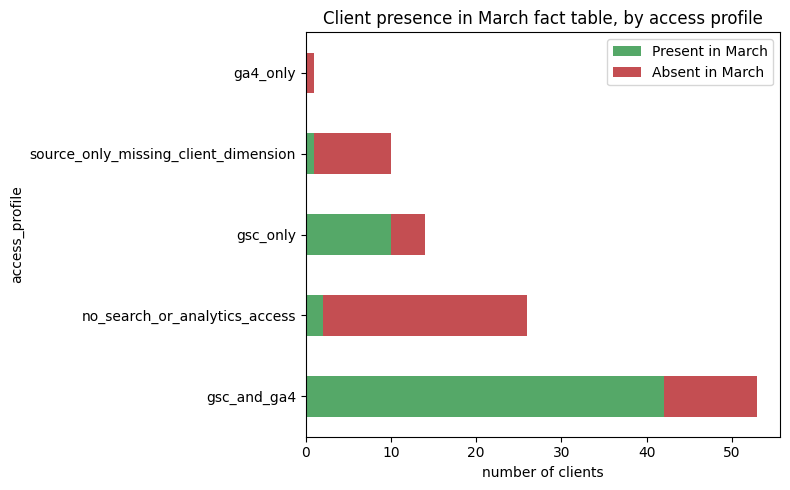

In [30]:
import pandas as pd

profile_data = con.sql("""
    SELECT
        access_profile,
        SUM(CASE WHEN client_hash_id IN (SELECT DISTINCT client_hash_id FROM fact) THEN 1 ELSE 0 END) AS present,
        COUNT(*) - SUM(CASE WHEN client_hash_id IN (SELECT DISTINCT client_hash_id FROM fact) THEN 1 ELSE 0 END) AS absent
    FROM dim_clients
    GROUP BY access_profile
    ORDER BY present + absent DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
profile_data.set_index("access_profile")[["present", "absent"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#55A868", "#C44E52"]
)
ax.set_xlabel("number of clients")
ax.set_title("Client presence in March fact table, by access profile")
ax.legend(["Present in March", "Absent in March"])

plt.tight_layout()
plt.savefig("work/figures/w03_client_panel_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

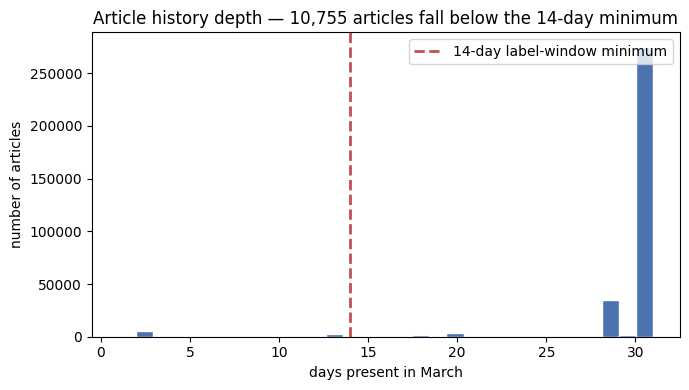

In [31]:
history = con.sql("""
    SELECT content_hash_id, COUNT(DISTINCT report_date) AS days_present
    FROM fact
    GROUP BY content_hash_id
""").df()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(history["days_present"], bins=31, color="#4C72B0", edgecolor="white")
ax.axvline(14, color="#C44E52", linestyle="--", linewidth=2, label="14-day label-window minimum")
ax.set_xlabel("days present in March")
ax.set_ylabel("number of articles")
ax.set_title("Article history depth — 10,755 articles fall below the 14-day minimum")
ax.legend()

plt.tight_layout()
plt.savefig("work/figures/w03_article_history_depth.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings:**

- *Of the 49 clients absent from March, most are explained: 24 of 26 `no_search_or_analytics_access` clients are absent (expected — no data source connected), and 9 of 10 `source_only_missing_client_dimension` clients are absent (this profile name itself signals an incomplete client record, a data-quality limit rather than a filtering choice).*
- ***Anomaly worth flagging:** 2 clients tagged `no_search_or_analytics_access` still appear in the March fact table. If this profile means "no data source connected," these rows shouldn't exist — either the profile label is stale relative to `fact`, or access was granted/revoked mid-panel and the dimension wasn't updated. Not resolved here; noted as an open question rather than silently ignored.*
- *`gsc_and_ga4` (the largest group, 53 clients) is mostly represented in March — 42 present, 11 absent — likely explained by `gsc_data_start` / `ga4_data_start` postdating the window rather than lack of access.*
- *Combined with §1–§3: this dataset can speak confidently about client-months where `gsc_data_available IS TRUE`, cannot distinguish GA4 non-engagement from non-access without using the three-valued flag correctly, has real content-metadata gaps (~32% missing `word_count`), and is a single-month snapshot — no feature built here can capture trend or seasonality*.

***Follow-up on the profile anomaly:** both clients labeled `no_search_or_analytics_access` have a real `gsc_data_start` (2025-11-05) despite `ga4_data_start` being null and the profile name implying no access at all. One has 8,060 March rows and 11,719 total impressions — clearly real GSC data. This confirms the `access_profile` label is **stale relative to `fact`**, not a query artifact: these clients had GSC access at some point (evidenced by `gsc_data_start` and real impressions) but are mislabeled as having none. Any lane that filters by `access_profile` alone, rather than by the row-level flags (`gsc_data_available`/`ga4_data_available`), risks silently dropping clients with real usable history.*

***Within-month history depth — client level:** of the 55 clients present in March, 4 have a partial month (min 9 days, max 31, avg 29.9 days). Most clients have close to the full 31 days, but a handful don't — worth checking per-client day count before assuming uniform coverage in any client-level aggregation.*

***Within-month history depth — article level:** far more uneven than clients. Article-level days-present ranges from 1 to 31 (avg 29.7), but **10,755 articles have under 14 days of March history**. Since the assumed label design (§2) needs roughly a 7-day-back / 7-day-forward window per article, any article with under ~14 days simply cannot support that label reliably — these articles should either be excluded from label construction or handled with a shorter/adaptive window, not silently included with a partial, misleading signal.*

## Summary

This slice — `fact_content_daily_performance`, March 2026, joined to `dim_content` and `dim_clients` — supports a click-growth lane at the article×day grain, but with real constraints: GSC signal is trustworthy when its own flag says so, GA4's flag is three-valued and easy to misread, ~2% of rows sit on deleted content, a third of articles lack `word_count`, and roughly 10,755 articles don't have enough March history to support a 7-day forward/back label. The `access_profile` field in `dim_clients` was also found to be stale for at least 2 clients — row-level flags, not that column, should drive any filtering.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [33]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/figures/w03_ai_rate_by_grain.png
	work/figures/w03_article_history_depth.png
	work/figures/w03_client_panel_imbalance.png
	work/figures/w03_column_coverage.png
	work/figures/w03_ga4_flag_breakdown.png

nothing added to commit but untracked files present (use "git add" to track)


In [34]:
import subprocess
from google.colab import userdata

GH_TOKEN = userdata.get('GH_TOKEN')
REPO = "whozahm3d/flyrank-ml-internship"

figures = [
    "work/figures/w03_ai_rate_by_grain.png",
    "work/figures/w03_article_history_depth.png",
    "work/figures/w03_client_panel_imbalance.png",
    "work/figures/w03_column_coverage.png",
    "work/figures/w03_ga4_flag_breakdown.png",
]

subprocess.run(["git", "add"] + figures, check=True)
subprocess.run(["git", "config", "user.email", "whozahm3d@gmail.com"], check=True)
subprocess.run(["git", "config", "user.name", "Ali Ahmad"], check=True)
subprocess.run(["git", "commit", "-m", "Add w03 visualizations"], check=True)

push_url = f"https://{GH_TOKEN}@github.com/{REPO}.git"
subprocess.run(["git", "push", push_url, "main"], check=True)

print("Pushed 5 w03 figures")

Pushed 5 w03 figures
